In [1]:
import numpy as np
import tensorflow as tf
import requests
import re
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [2]:
import torch
print(torch.__version__)

2.10.0+cu128


In [3]:
import torch
print(torch.cuda.is_available())

True


In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print(text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
text = text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Reduce dataset size (IMPORTANT for Colab)
text = text[:150000]

In [4]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts([text])

total_words = 5000

token_list = tokenizer.texts_to_sequences([text])[0]

In [29]:
sequence_length = 10
input_sequences = []
output_words = []

for i in range(sequence_length, len(token_list)):
    input_sequences.append(token_list[i-sequence_length:i])
    output_words.append(token_list[i])

X = np.array(input_sequences)
y = np.array(output_words)   # NO one-hot encoding

print(X.shape, y.shape)

(28309, 10) (28309,)


In [30]:
model = Sequential()

model.add(Embedding(5000, 64, input_length=sequence_length))
model.add(LSTM(64))   # reduced size
model.add(Dense(5000, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(X, y, epochs=20, batch_size=64)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0371 - loss: 6.7910
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0385 - loss: 6.3642
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0432 - loss: 6.2729
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0490 - loss: 6.1652
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0532 - loss: 6.0570
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0596 - loss: 5.9590
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0640 - loss: 5.8589
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0686 - loss: 5.7546
Epoch 9/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0745 - loss: 5.6481
Epoch 10/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0829 - loss: 5.5325
Epoch 11/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0900 - loss: 5.4166
Epoch 12/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

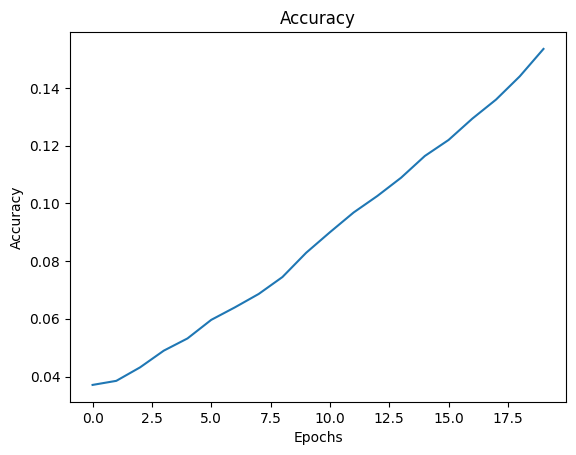

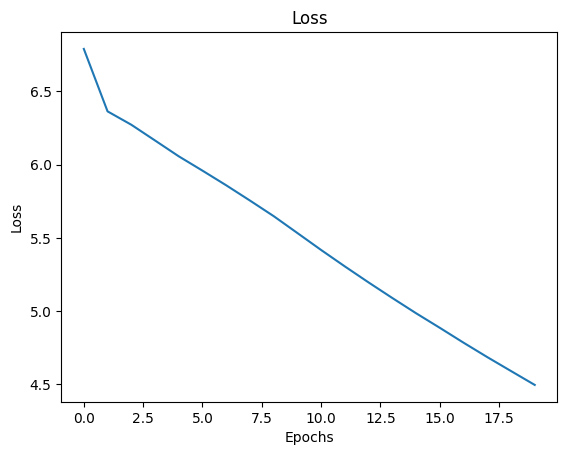

In [32]:
plt.plot(history.history['accuracy'])
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [33]:
def sample_with_temperature(preds, temperature=0.7):
    preds = np.log(preds + 1e-8) / temperature
    preds = np.exp(preds)
    preds = preds / np.sum(preds)
    return np.random.choice(len(preds), p=preds)

In [34]:
def generate_text(seed_text, next_words):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=sequence_length, padding='pre')

        preds = model.predict(token_list)[0]
        predicted = sample_with_temperature(preds, 0.7)

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                seed_text += " " + word
                break

    return seed_text

In [35]:
text = re.sub(r'[^a-zA-Z\s]', '', text)

In [36]:
print(generate_text("the king", 10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
the king of war not i have let us marcius let him
